In [1]:
import pandas as pd 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sentence_transformers import SentenceTransformer
import torch
from torch.nn import functional as F
from transformers import AutoTokenizer, AutoModelForMaskedLM
import umap.umap_ as umap
import numpy as np
import re

df = pd.read_csv("/Users/iseult/Desktop/Trait_Assignment/Trait.data.tsv", sep = '\t')
df['title'] = (
    df['title']
    .str.replace(r'\b(exclud(?:e|es|ing)?|except)\b.*', '', flags=re.IGNORECASE, regex=True)
    .str.strip()
)

df.head(50)

,index,study,accession,title,coding_targets,regulatory_targets
0,1,FinnGen,AB1_BACTINF_NOS,"Bacterial infection, other or unspecified",1,10
1,2,FinnGen,AB1_ERYSIPELAS,Erysipelas,3,46
2,3,FinnGen,AB1_GASTROENTERITIS_NOS,Diarrhoea and gastroenteritis of presumed infe...,14,100
3,4,FinnGen,AB1_LYME,Lyme disease,1,3
4,5,FinnGen,AB1_OTHER_SUPERF_MYCOSIS,Other superficial mycoses,5,79
5,6,FinnGen,AB1_PARASITIC_NOS,Unspecified parasitic disease,2,22
6,7,FinnGen,AB1_SEXUAL_TRANSMISSION_NOS,Other predominantly sexually transmitted disea...,71,269
7,8,FinnGen,AB1_VIRAL_HEMOR_FEVER_NOS,"Viral haemorrhagic fevers, not elsewhere class...",20,119
8,9,FinnGen,AB1_VIRAL_OTHER_INTEST_INFECTIONS,Viral and other specified intestinal infections,8,72
9,10,FinnGen,AB1_VIRAL_WARTS,Viral warts,16,113


In [12]:
category_descriptions = { 
    # Cardiovascular
    "Cardiovascular": ["coronary", "heart failure", "myocardial infarction", "cardiomyopathy", "arrhythmia", "hypertension", "stroke", "atherosclerosis", "anemia", "thrombosis", "blood", "heart rate", "heart", "arteries", "veins", "atria", "ventricles", "aorta", "valves", "circulation", "platelet"],

    # Metabolic 
    "Metabolic": ["diabetes", "obesity", "hyperglycemia", "dyslipidemia", "hypercholesterolemia", "insulin resistance", "fatty liver", "insulin", "glucose", "body mass index", "mass", "weight", "height", "fat free mass", "metabolic", "metabolic rate"],
    
    # Endocrine
    "Thyroid Disorders": ["hyperthyroidism", "hypothyroidism", "thyroiditis", "goiter", "graves", "hashimoto", "gout"],

    # Respiratory
    "Respiratory Disorders": ["pneumonia", "asthma", "lung capacity", "breathing problems", "bronchitis", "lung", "breathing", "respiration", "eosinophill"],

    # Immune / Inflammatory
    "Autoimmune Disorders": ["crohn", "ulcerative colitis", "immunodeficiency", "autoimmune", "cytokine", "immune", "lymphocyte", "leukocytes", "cytotoxic T cells", "dendritic cells", "helper T cells", "macrophages", "arthritis", "psoriasis", "inflammation"],

    # Infection
    "Infection": ["infection", "fever", "viral", "bacterial", "parasitic"],
    
    # Cancer
    "Cancer / Neoplastic Diseases": ["cancer", "carcinoma", "sarcoma", "leukemia", "lymphoma", "melanoma", "tumor", "metastasis", "oncogene", "neoplasm"],

    # Neurological / Psychiatric
    "Neurodegenerative": ["alzheimer", "parkinson", "dementia", "hypomyelination", "senility", "neurodegenerative", "memory", "brain", "cognition", "neuron", "mental health", "epilepsy", "autism", "schizophrenia", "depression", "bipolar"],

    # Developmental
    "Developmental Disorders": ["dysplasia", "spastic", "developmental delay", "skeletal dysplasia", "craniofacial anomaly", "cleft", "microcephaly"],

    # Reproductive / Fertility
    "Reproductive / Fertility Disorders": ["infertility", "amenorrhea", "pcos", "endometriosis", "sperm abnormality", "ovarian failure", "testicular dysfunction"],

    # Musculoskeletal
    "Musculoskeletal Disorders": ["osteoporosis", "sciatica", "spondylopathy", "myopathy", "muscular dystrophy", "arthritis", "bone fracture", "muscle", "bone", "injury"],

    # Renal
    "Renal Disorders": ["incontinence", "cystitis", "urinary tract infection", "kidney disease"],

    # Lifestyle / Diet
    "Diet": ["alcohol", "sugar", "smoking", "obesity"],

    # Medication
    "Medication": ["treatment", "dosage", "prescribed"],

    # Catch-all / lifestyle
    "Lifestyle / Behavioral": ["exercise", "sleep", "nutrition", "wellbeing"],
    
    "Environmental Exposure": ["air pollution", "noise", "sunlight exposure", "chemical exposure"],

    "General Health / Anthropometric": ["height", "weight", "BMI", "lean mass", "fat mass"],

    "Socioeconomic / Demographic": ["income", "education level", "employment status", "neighborhood deprivation index"],

}

In [13]:
# Load a biomedical embedding model
#model = SentenceTransformer('microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext')
model = SentenceTransformer('menadsa/S-BlueBERT')
# Create the category embeddings
category_names = list(category_descriptions.keys())
category_texts = list(category_descriptions.values())
category_embeddings = model.encode(category_texts, convert_to_tensor=True)

traits = df['title'].astype(str).tolist()
trait_embeddings = model.encode(traits, convert_to_tensor=True)

In [14]:
trait_embeddings = F.normalize(trait_embeddings, p=2, dim=1)
category_embeddings = F.normalize(category_embeddings, p=2, dim=1)

# Compute cosine similarity between each trait and each category
similarities = trait_embeddings @ category_embeddings.T

# Find best match and its similarity score
max_sim, best_idx = torch.max(similarities, dim=1)
best_idx = best_idx.cpu().numpy()
max_sim = max_sim.cpu().numpy()

# Threshold for confident assignment
threshold = 0.10  # you can tune this (0.25–0.40 often works well)

# Assign categories (or leave unassigned)
df['Predicted_Category'] = [
    category_names[i] if s > threshold else "Unassigned"
    for i, s in zip(best_idx, max_sim)
]
df['Category_Similarity'] = max_sim
df.to_csv("/Users/iseult/Desktop/Trait_Assignment/Trait_PredictedCategory.csv")

/Users/iseult/.python/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


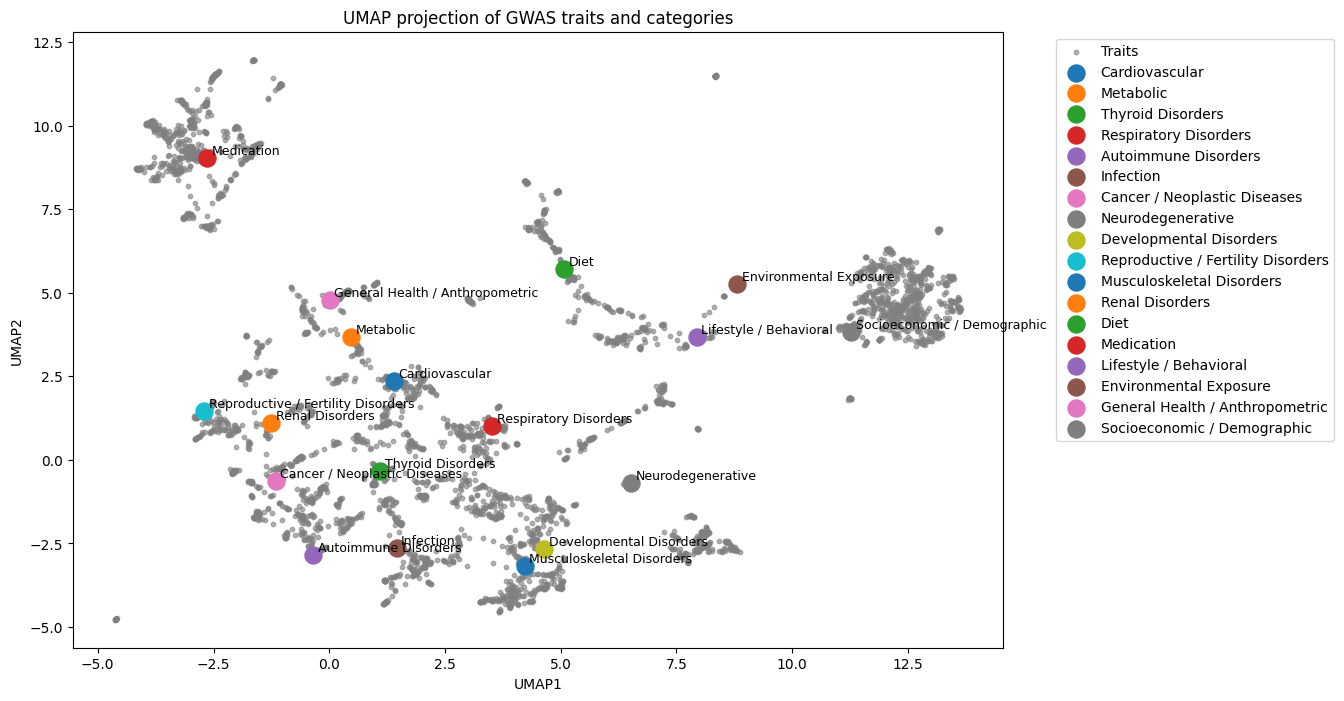

In [15]:
# Convert embeddings to numpy
trait_emb_np = trait_embeddings.cpu().numpy()
category_emb_np = category_embeddings.cpu().numpy()

# Concatenate traits + categories for a shared projection
all_embeddings = np.vstack([trait_emb_np, category_emb_np])

# Fit UMAP (you can adjust n_neighbors / min_dist)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(all_embeddings)

# Split back into traits and categories
trait_2d = embedding_2d[:len(trait_emb_np)]
category_2d = embedding_2d[len(trait_emb_np):]

# Plot
plt.figure(figsize=(12, 8))

# Plot traits
plt.scatter(trait_2d[:, 0], trait_2d[:, 1], s=10, c='gray', alpha=0.6, label='Traits')

# Plot categories
for i, name in enumerate(category_names):
    plt.scatter(category_2d[i, 0], category_2d[i, 1], s=150, label=name)
    plt.text(category_2d[i, 0]+0.1, category_2d[i, 1]+0.1, name, fontsize=9)

plt.title("UMAP projection of GWAS traits and categories")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

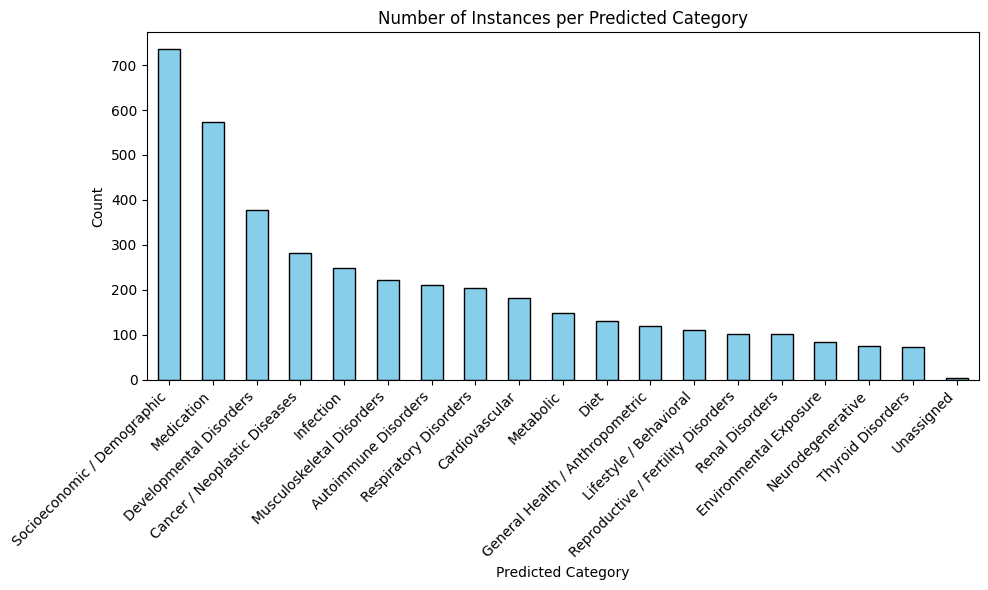

In [16]:
# Count the number of instances of each category
category_counts = df['Predicted_Category'].value_counts()

# Plot the counts
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Number of Instances per Predicted Category')
plt.xlabel('Predicted Category')
plt.ylabel('Count')

# Improve readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [17]:
# Set the categories to assign each trait from Ramil's table
category_descriptions = { 
    # Cardiovascular
    "Cardiac Disorders": ["coronary", "heart failure", "myocardial infarction", "cardiomyopathy", "arrhythmia"],
    "Vascular Disorders": ["hypertension", "stroke", "atherosclerosis", "anemia", "thrombosis"],
    "Cardiovascular Physiology": ["blood", "heart rate", "heart", "arteries", "veins", "atria", "ventricles", "aorta", "valves", "circulation", "platelet"],

    # Metabolic & Endocrine
    "Metabolic Disorders": ["diabetes", "obesity", "hyperglycemia", "dyslipidemia", "hypercholesterolemia", "insulin resistance", "fatty liver"],
    "Metabolic Physiology": ["insulin", "glucose", "body mass index", "mass", "weight", "height", "fat free mass", "metabolic", "metabolic rate"],
    "Thyroid Disorders": ["hyperthyroidism", "hypothyroidism", "thyroiditis", "goiter", "graves", "hashimoto", "gout"],
    "Thyroid Physiology": ["endocrine", "hormone"],

    # Respiratory
    "Respiratory Disorders": ["pneumonia", "asthma", "lung capacity", "breathing problems", "bronchitis"],
    "Respiratory Physiology": ["lung", "breathing", "respiration", "eosinophill"],

    # Immune / Inflammatory
    "Autoimmune Disorders": ["crohn", "ulcerative colitis", "immunodeficiency", "autoimmune"],
    "Inflammatory Disorders": ["arthritis", "psoriasis", "cytokine storm", "inflammation"],
    "Immune Physiology": ["cytokine", "immune", "lymphocyte", "leukocytes", "lymphocytes", "cytotoxic T cells", "dendritic cells", "helper T cells", "macrophages"],
    "Infection": ["infection", "fever", "viral", "bacterial", "parasitic"],

    # Cancer
    "Cancer / Neoplastic Diseases": ["cancer", "carcinoma", "sarcoma", "leukemia", "lymphoma", "melanoma", "tumor", "metastasis", "oncogene", "neoplasm"],

    # Neurological / Psychiatric
    "Neurodegenerative Disorders": ["alzheimer", "parkinson", "dementia", "hypomyelination", "senility", "neurodegenerative"],
    "Psychiatric / Mental Health Disorders": ["epilepsy", "autism", "schizophrenia", "depression", "bipolar", "migraine", "suicide", "self-harm"],
    "Neurological Physiology": ["memory", "brain", "cognition", "neuron", "mental health"],

    # Developmental
    "Developmental Disorders": ["dysplasia", "spastic", "developmental delay", "skeletal dysplasia", "craniofacial anomaly", "cleft", "microcephaly"],

    # Reproductive / Fertility
    "Reproductive / Fertility Disorders": ["infertility", "amenorrhea", "pcos", "endometriosis", "sperm abnormality", "ovarian failure", "testicular dysfunction"],

    # Musculoskeletal
    "Musculoskeletal Disorders": ["osteoporosis", "sciatica", "spondylopathy", "myopathy", "muscular dystrophy", "arthritis", "bone fracture"],
    "Musculoskeletal Physiology": ["muscle", "bone", "injury"],

    # Renal
    "Renal Disorders": ["incontinence", "cystitis", "urinary tract infection", "kidney disease"],

    # Lifestyle / Diet
    "Diet / Lifestyle": ["alcohol", "sugar", "smoking"],

    # Catch-all / lifestyle
    "Lifestyle / Behavioral": ["exercise", "sleep", "nutrition", "wellbeing"],
    
    "Environmental Exposure": ["air pollution", "noise", "sunlight exposure", "chemical exposure"],

    "General Health / Anthropometric": ["height", "weight", "BMI", "lean mass", "fat mass"],

    "Socioeconomic / Demographic": ["income", "education level", "employment status", "neighborhood deprivation index"],

    "Medication": ["treatment", "dosage", "prescribed"]

}

In [18]:
# Load a biomedical embedding model
#model = SentenceTransformer('microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext')
model = SentenceTransformer('menadsa/S-BlueBERT')
# Create the category embeddings
category_names = list(category_descriptions.keys())
category_texts = list(category_descriptions.values())
category_embeddings = model.encode(category_texts, convert_to_tensor=True)

traits = df['title'].astype(str).tolist()
trait_embeddings = model.encode(traits, convert_to_tensor=True)

In [19]:
trait_embeddings = F.normalize(trait_embeddings, p=2, dim=1)
category_embeddings = F.normalize(category_embeddings, p=2, dim=1)

# Compute cosine similarity between each trait and each category
similarities = trait_embeddings @ category_embeddings.T

# Find best match and its similarity score
max_sim, best_idx = torch.max(similarities, dim=1)
best_idx = best_idx.cpu().numpy()
max_sim = max_sim.cpu().numpy()

# Threshold for confident assignment
threshold = 0.10  # you can tune this (0.25–0.40 often works well)

# Assign categories (or leave unassigned)
df['Predicted_Category'] = [
    category_names[i] if s > threshold else "Unassigned"
    for i, s in zip(best_idx, max_sim)
]
df['Category_Similarity'] = max_sim

df.to_csv("/Users/iseult/Desktop/Trait_Assignment/Trait_PredictedCategory_more.csv")

/Users/iseult/.python/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


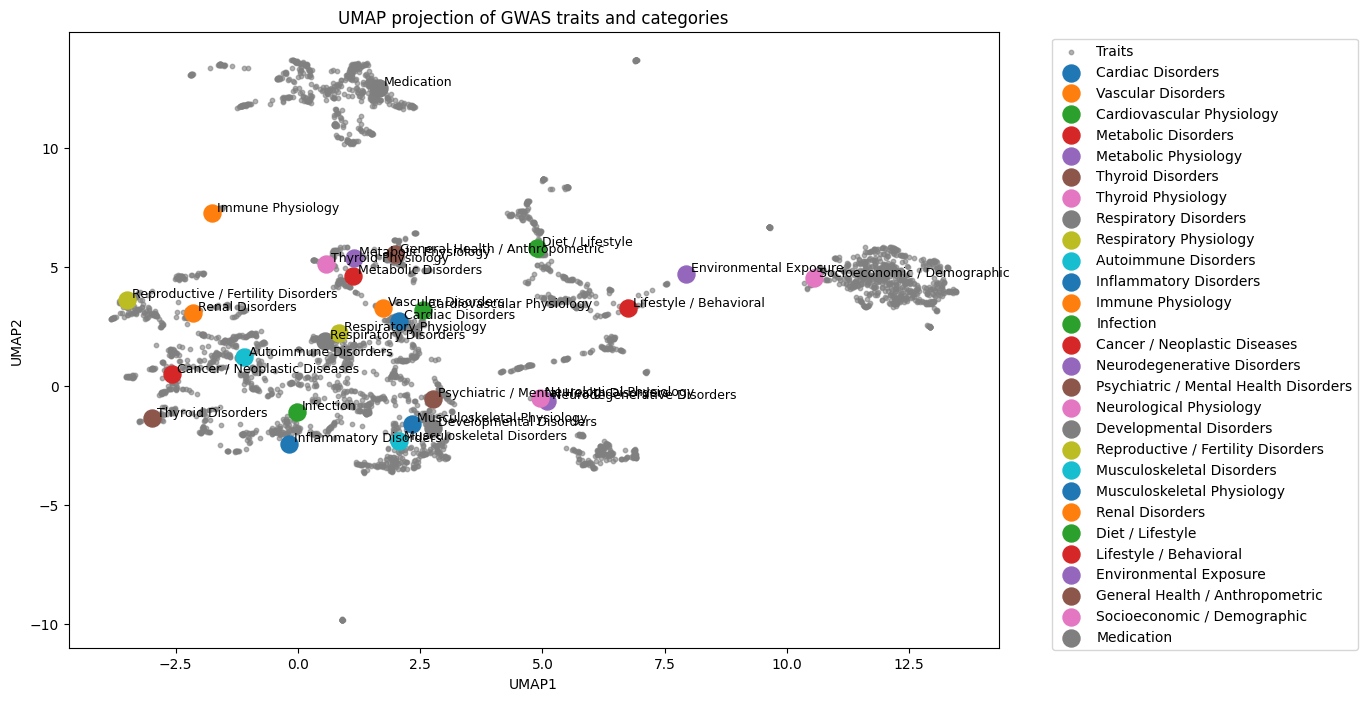

In [20]:
# Convert embeddings to numpy
trait_emb_np = trait_embeddings.cpu().numpy()
category_emb_np = category_embeddings.cpu().numpy()

# Concatenate traits + categories for a shared projection
all_embeddings = np.vstack([trait_emb_np, category_emb_np])

# Fit UMAP (you can adjust n_neighbors / min_dist)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(all_embeddings)

# Split back into traits and categories
trait_2d = embedding_2d[:len(trait_emb_np)]
category_2d = embedding_2d[len(trait_emb_np):]

# Plot
plt.figure(figsize=(12, 8))

# Plot traits
plt.scatter(trait_2d[:, 0], trait_2d[:, 1], s=10, c='gray', alpha=0.6, label='Traits')

# Plot categories
for i, name in enumerate(category_names):
    plt.scatter(category_2d[i, 0], category_2d[i, 1], s=150, label=name)
    plt.text(category_2d[i, 0]+0.1, category_2d[i, 1]+0.1, name, fontsize=9)

plt.title("UMAP projection of GWAS traits and categories")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

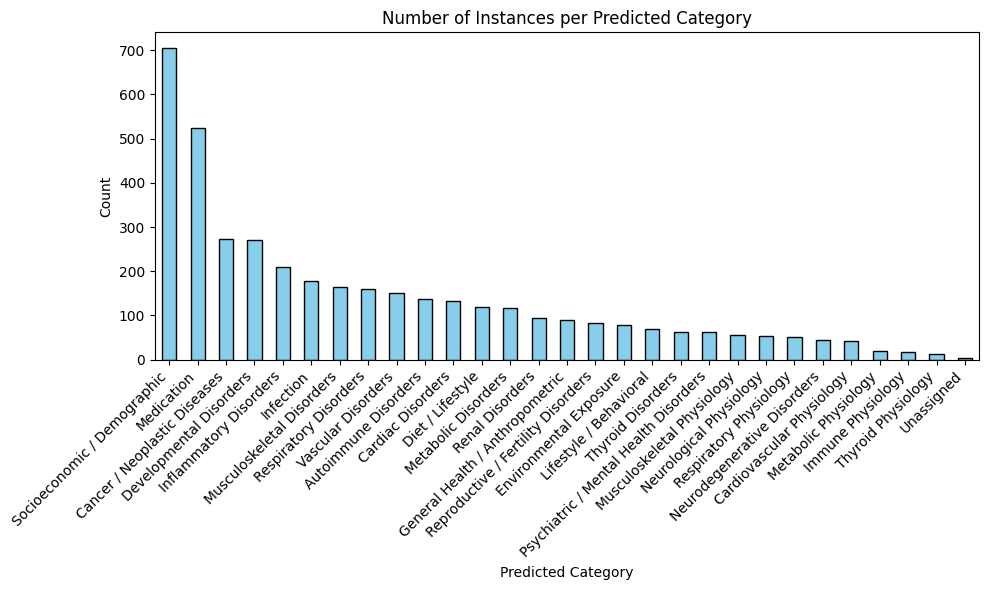

In [21]:
# Count the number of instances of each category
category_counts = df['Predicted_Category'].value_counts()

# Plot the counts
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Number of Instances per Predicted Category')
plt.xlabel('Predicted Category')
plt.ylabel('Count')

# Improve readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [22]:
df[df["Predicted_Category"] == "Unassigned"]

,index,study,accession,title,coding_targets,regulatory_targets,Predicted_Category,Category_Similarity
3,4,FinnGen,AB1_LYME,Lyme disease,1,3,Unassigned,0.238611
4,5,FinnGen,AB1_OTHER_SUPERF_MYCOSIS,Other superficial mycoses,5,79,Unassigned,0.226815
5,6,FinnGen,AB1_PARASITIC_NOS,Unspecified parasitic disease,2,22,Unassigned,0.202719
7,8,FinnGen,AB1_VIRAL_HEMOR_FEVER_NOS,"Viral haemorrhagic fevers, not elsewhere class...",20,119,Unassigned,0.189410
9,10,FinnGen,AB1_VIRAL_WARTS,Viral warts,16,113,Unassigned,0.250646
...,...,...,...,...,...,...,...,...
3974,3975,UKBB,Z52,Diagnoses - main ICD10: Z52 Donors of organs a...,432,349,Unassigned,0.187533
3975,3976,UKBB,Z53,Diagnoses - main ICD10: Z53 Persons encounteri...,337,248,Unassigned,0.243957
3976,3977,UKBB,Z71,Diagnoses - main ICD10: Z71 Persons encounteri...,409,381,Unassigned,0.254626
3977,3978,UKBB,Z76,Diagnoses - main ICD10: Z76 Persons encounteri...,479,550,Unassigned,0.260459
